In [ ]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                                     concatenate)
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / \
           (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def jaccard_index(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [ ]:
# Base directories - Updated for MedPlant dataset structure
import os
import glob

# MedPlant dataset paths
medplant_root = "/kaggle/input/medplants-data/MedPlant-dataset-master/MedPlant"
train_plant_dirs = sorted([d for d in glob.glob(os.path.join(medplant_root, "train_data", "*")) if os.path.isdir(d)])
test_plant_dirs = sorted([d for d in glob.glob(os.path.join(medplant_root, "test_data", "*")) if os.path.isdir(d)])

print(f"Found {len(train_plant_dirs)} plant species in training data")
print(f"Found {len(test_plant_dirs)} plant species in test data")
print(f"Plant species: {[os.path.basename(d) for d in train_plant_dirs]}")

# For simplicity, use the first plant species for now
if train_plant_dirs:
    train_img_dir = os.path.join(train_plant_dirs[0], "train_images")
    train_mask_dir = os.path.join(train_plant_dirs[0], "groundtruth_binary_masks")
    print(f"Using training data from: {train_plant_dirs[0]}")

if test_plant_dirs:
    test_img_dir = os.path.join(test_plant_dirs[0], "test_images")
    test_mask_dir = os.path.join(test_plant_dirs[0], "groundtruth_binary_masks")
    print(f"Using test data from: {test_plant_dirs[0]}")

# Image generators
img_gen = ImageDataGenerator(rescale=1./255)
mask_gen = ImageDataGenerator(rescale=1./255)

Found 5 plant species in training data
Found 5 plant species in test data
Plant species: ['Annona Muricata', 'Cestrum diurnum', 'Nyctanthes arbor-tristis', 'Ocimum Tenuforium', 'Psidium guajava']
Using training data from: /kaggle/input/medplants-data/MedPlant-dataset-master/MedPlant/train_data/Annona Muricata
Using test data from: /kaggle/input/medplants-data/MedPlant-dataset-master/MedPlant/test_data/Annona Muricata


In [ ]:
def create_segmentation_generator(image_dir, mask_dir, batch_size=4):
    """
    Creates a generator that yields paired image and mask batches.
    Adapted for MedPlant dataset where images and masks are in separate directories.
    """
    # Get sorted list of image files
    image_files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) +
                        glob.glob(os.path.join(image_dir, "*.png")))

    if not image_files:
        raise ValueError(f"No images found in {image_dir}")

    # Verify corresponding masks exist
    mask_files = []
    for img_file in image_files:
        base_name = os.path.basename(img_file)
        mask_file = os.path.join(mask_dir, base_name)
        if os.path.exists(mask_file):
            mask_files.append(mask_file)
        else:
            print(f"Warning: No mask found for {img_file}")

    print(f"Found {len(image_files)} images and {len(mask_files)} masks")

    if len(mask_files) == 0:
        raise ValueError(f"No matching masks found in {mask_dir}")

    # Generator function
    def generator():
        idx = 0
        while True:
            batch_images = []
            batch_masks = []

            for _ in range(batch_size):
                if idx >= len(image_files):
                    idx = 0  # Loop back to start

                # Load image
                img = tf.keras.preprocessing.image.load_img(
                    image_files[idx],
                    target_size=(128, 128),
                    color_mode='grayscale'
                )
                img_array = tf.keras.preprocessing.image.img_to_array(img)
                img_array = img_array / 255.0  # Normalize
                batch_images.append(img_array)

                # Load corresponding mask
                if idx < len(mask_files):
                    mask = tf.keras.preprocessing.image.load_img(
                        mask_files[idx],
                        target_size=(128, 128),
                        color_mode='grayscale'
                    )
                    mask_array = tf.keras.preprocessing.image.img_to_array(mask)
                    mask_array = mask_array / 255.0  # Normalize
                    batch_masks.append(mask_array)

                idx += 1

            yield (np.array(batch_images), np.array(batch_masks))

    return generator()

In [ ]:
batch_size = 4

# Create generators for train and test data
train_gen = create_segmentation_generator(train_img_dir, train_mask_dir, batch_size)
test_gen  = create_segmentation_generator(test_img_dir, test_mask_dir, batch_size)

Found 216 images and 216 masks
Found 52 images and 52 masks


In [ ]:
def build_unet(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)

    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D(2)(c2)

    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D(2)(c3)

    c4 = Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = MaxPooling2D(2)(c4)

    c5 = Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, 3, activation='relu', padding='same')(c5)

    u6 = Conv2DTranspose(512, 2, strides=2, padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(512, 3, activation='relu', padding='same')(c6)

    u7 = Conv2DTranspose(256, 2, strides=2, padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(256, 3, activation='relu', padding='same')(c7)

    u8 = Conv2DTranspose(128, 2, strides=2, padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = Conv2D(128, 3, activation='relu', padding='same')(c8)

    u9 = Conv2DTranspose(64, 2, strides=2, padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = Conv2D(64, 3, activation='relu', padding='same')(c9)

    outputs = Conv2D(1, 1, activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model


In [ ]:
model = build_unet()

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="binary_crossentropy",
              metrics=[dice_coef, jaccard_index])

model.summary()


I0000 00:00:1764481877.384346      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764481877.384944      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

Parameter formula for Conv2D:

Params=(Kh​×Kw​×Cin​+1)×Cout)
	​


In [ ]:
steps_train = 200  # depends on dataset size
steps_test  = 50

history = model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    validation_data=test_gen,
    validation_steps=steps_test,
    epochs=20
)


Epoch 1/20


I0000 00:00:1764481884.944675     112 service.cc:148] XLA service 0x7cf510002f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764481884.945545     112 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764481884.945571     112 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764481885.938731     112 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1764481892.537911     112 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764481892.749824     112 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/200 ━━━━━━━━━━━━━━━━━━━━ 1:15:59 23s/step - dice_coef: 0.3867 - jaccard_index: 0.2397 - loss: 0.6926

I0000 00:00:1764481901.731211     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - dice_coef: 0.3344 - jaccard_index: 0.2063 - loss: 0.5316 - val_dice_coef: 0.6652 - val_jaccard_index: 0.4996 - val_loss: 0.2549
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - dice_coef: 0.6641 - jaccard_index: 0.4997 - loss: 0.2653 - val_dice_coef: 0.7562 - val_jaccard_index: 0.6092 - val_loss: 0.1950
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - dice_coef: 0.7330 - jaccard_index: 0.5811 - loss: 0.2037 - val_dice_coef: 0.8051 - val_jaccard_index: 0.6750 - val_loss: 0.1534
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - dice_coef: 0.8065 - jaccard_index: 0.6785 - loss: 0.1499 - val_dice_coef: 0.8681 - val_jaccard_index: 0.7680 - val_loss: 0.1238
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - dice_coef: 0.8748 - jaccard_index: 0.7794 - loss: 0.0985 - val_dice_coef: 0.8751 - val_jaccard_index: 0.7800 - val_loss: 0.1289
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - dice_coef: 0.8952 - jaccard_in

In [ ]:
test_imgs, test_masks = next(test_gen)

pred = model.predict(test_imgs)
pred_bin = (pred > 0.5).astype("float32")

print("Dice:", dice_coef(test_masks, pred_bin).numpy())
print("Jaccard:", jaccard_index(test_masks, pred_bin).numpy())


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
Dice: 0.9784691
Jaccard: 0.95784575


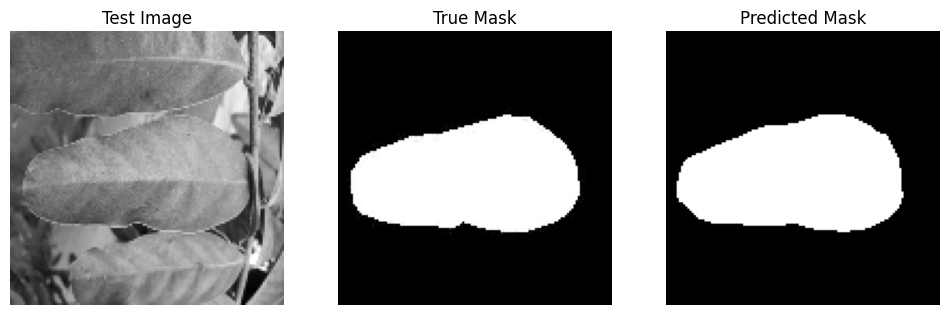

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Test Image")
plt.imshow(test_imgs[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(test_masks[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_bin[0].squeeze(), cmap='gray')
plt.axis('off')

plt.show()


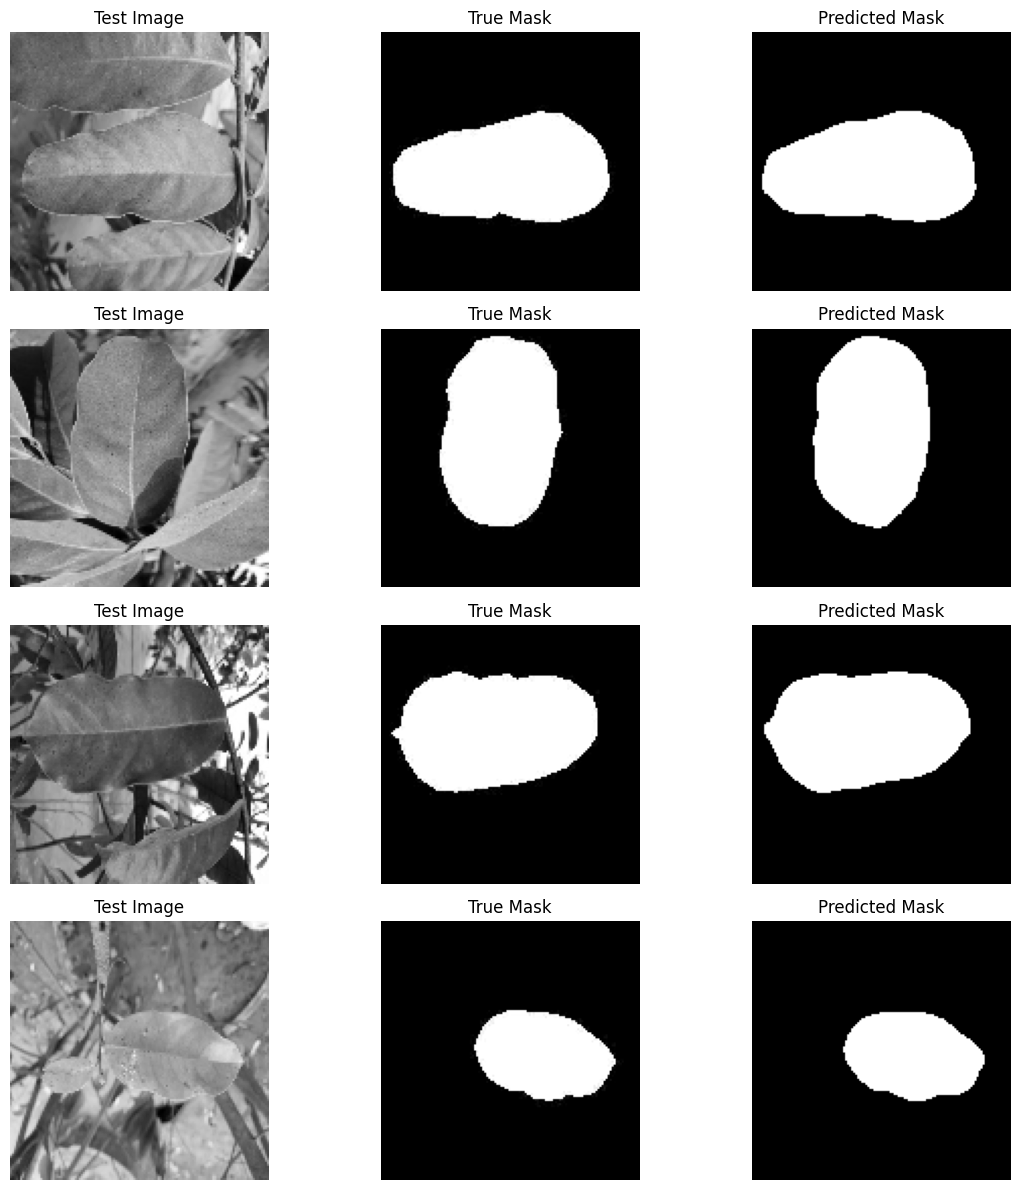

In [ ]:
num_samples = min(5, test_imgs.shape[0])  # Show up to 4 samples

plt.figure(figsize=(12, 3 * num_samples))

for i in range(num_samples):
    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.title("Test Image")
    plt.imshow(test_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.title("True Mask")
    plt.imshow(test_masks[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.title("Predicted Mask")
    plt.imshow(pred_bin[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()